# 完整小波序列：连续状态、时刻对齐与独立单图

本单元将 [c01 小波变换](c01_WaveletTransform.ipynb) 和 [c02 同步压缩](c02_Synchrosqueezing.ipynb) 接入带采样坐标的完整序列。输入值直接使用；核、周期、预热、频率网格和阈值由调用者指定。默认因果 Gammatone 连续递推，不按日期、Session、训练／测试或绘图窗口重新初始化。

|入口|用途|
|---|---|
|`WaveletSequenceState`|携带 c01 滤波状态、最后采样坐标及此前输入的可得时刻|
|`build_wavelet_sequence_schema`|明确核、通道及频率网格对应的局部 Arrow 保存契约|
|`compute_wavelet_sequence`|接收连续采样行，计算 CWT 和可选 SST，保留坐标、状态与复系数|
|`plot_wavelet_sequence`|只读取已有序列表；每次返回一张图，由参数选择 CWT／SST 的幅值、能量或相位|

名称中的 Rolling 表示随采样点推进，计算首版采用连续状态。单次调用可计算整段，也可将 `final_state` 传给下一连续块；不提供窗口重置功能。Morlet 按整段离线计算，不接受递推状态，也不据其结果填写因果可得时刻。

In [1]:
from pathlib import Path
import sys
project_markers = [".git", ".env", "config/settings.py"]
current_path = Path.cwd().resolve()
for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        break
else:
    raise RuntimeError("未找到项目根目录")


## 输入顺序与时刻含义

`samples_df` 必须包含 `sample_id`、`sample_at`、`bar_at`、`trading_date`、`sample_side` 及 `value_col`。采样编号为连续整数，位置时刻按行不递减，两种时刻均为同一时区且非空；这定义本方法每推进一行就是一个采样点的前提。日期和训练／测试字段只作坐标，不触发状态变化。续算块必须从上一块编号的下一点开始，重叠、跳号或时刻倒退明确报错，不以重置、排序或补行掩盖缺少的采样点。缺失数值必须保留在其采样行，以 NaN／Inf 交给 c01 记录和分段。

`input_available_at[n]` 为到当前点为止，所有 `sample_at` 和源 `bar_at` 的最大值；续算时包含前一块的历史最大值。它避免将较晚源报价所支持的输入登记到较早采样位置。因果输出至少有一个尺度就绪时，`available_at` 采用该历史最大值；没有就绪尺度时为空。`analysis_context_end_at` 对因果计算等于当前输入可得时刻，对 Morlet 等于所给整段输入的最终时刻，表示离线计算使用的上下文。Morlet 的 `available_at` 始终为空，`is_causal=False`。

这些字段描述调用时提供的输入坐标与本方法的计算依赖。上游采样或输入变换自身的可得性仍由上游契约决定。滤波响应滞后保留在核组的 `group_delay_samples` 中，不回移结果时间戳。周期始终表示采样点数；休市造成的自然时间间隔不插入额外采样点。

因果续算状态仅在内存中显式传递。本单元不保存或自动恢复检查点；停机后的复现须重新提供历史输入，或由调用者另行保存完整状态。

In [2]:
from dataclasses import dataclass
import hashlib
import json
import numpy as np
import pandas as pd
import pyarrow as pa
from config.data_contracts import pandas_to_arrow
from R04_Research.a01_Methods.b06_WaveletAnalysis.c01_WaveletTransform import (
    WaveletBank, WaveletState, build_wavelet_bank, compute_wavelet_transform,
    WAVELET_CHANNEL_SCHEMA, WAVELET_COEFFICIENT_SCHEMA,
)
from R04_Research.a01_Methods.b06_WaveletAnalysis.c02_Synchrosqueezing import (
    SSTFrequencyGrid, build_sst_frequency_grid, compute_sst, SST_POINT_FIELDS,
    SST_COLUMN_LABELS,
)

ROLLING_WAVELET_VERSION = '0.1.0'

@dataclass(frozen=True)
class WaveletSequenceState:
    wavelet_state: WaveletState
    last_sample_id: int | None
    last_sample_at: pd.Timestamp | None
    last_input_available_at: pd.Timestamp | None
    processed_sample_count: int

WAVELET_SEQUENCE_POINT_FIELDS = [
    pa.field('sample_id',pa.int64()),pa.field('sample_at',pa.timestamp('us',tz='Asia/Shanghai')),
    pa.field('bar_at',pa.timestamp('us',tz='Asia/Shanghai')),pa.field('trading_date',pa.date32()),
    pa.field('sample_side',pa.string()),pa.field('input_value',pa.float64()),pa.field('is_causal',pa.bool_()),
    *[pa.field(name,pa.timestamp('us',tz='Asia/Shanghai')) for name in
      ['input_available_at','available_at','analysis_context_end_at']],
    pa.field('segment_id',pa.int64()),pa.field('segment_sample_count',pa.int64()),
    *[pa.field(name,pa.int64()) for name in ['cwt_ready_scale_count','cwt_failed_scale_count',
        'cwt_warmup_scale_count','cwt_boundary_scale_count']],
    pa.field('cwt_status',pa.string()),pa.field('cwt_reason',pa.string()),
]

def build_wavelet_sequence_schema(bank: WaveletBank, frequency_grid=None, *, sst_method='formal') -> pa.Schema:
    """按既定核和网格构造宽表契约；不读取、计算或保存数据。"""
    if sst_method not in ('formal','legacy_sum'):
        raise ValueError('sst_method 必须为 formal 或 legacy_sum')
    channel_count = len(bank.channels_df)
    fields = [*WAVELET_SEQUENCE_POINT_FIELDS]
    for channel in range(channel_count):
        for name in ['cwt_real','cwt_imag','derivative_real','derivative_imag']:
            fields.append(pa.field(f'{name}_{channel:03d}',pa.float64()))
        for name in ['transform_status','transform_reason']:
            fields.append(pa.field(f'{name}_{channel:03d}',pa.string()))
    if frequency_grid is not None:
        fields.extend(SST_POINT_FIELDS[5:])
        for channel in range(channel_count):
            for name in ['if_raw_frequency','if_frequency','if_period_samples','if_model_angular_frequency']:
                fields.append(pa.field(f'{name}_{channel:03d}',pa.float64()))
            fields.append(pa.field(f'assigned_bin_{channel:03d}',pa.int64()))
            for name in ['if_status','if_reason','reassignment_status','reassignment_reason']:
                fields.append(pa.field(f'{name}_{channel:03d}',pa.string()))
        for component in ['real','imag']:
            for interval in range(len(frequency_grid.edges)-1):
                fields.append(pa.field(f'sst_{component}_{interval:03d}',pa.float64()))
    metadata = dict(method='rolling_wavelet',schema_version=ROLLING_WAVELET_VERSION,
        kernel_type=bank.kernel_type,bank_signature=bank.signature,n_channels=str(channel_count),
        is_causal=str(bank.parameters['is_causal']).lower(),has_sst=str(frequency_grid is not None).lower(),
        n_bins=str(0 if frequency_grid is None else len(frequency_grid.edges)-1),
        frequency_grid_signature='' if frequency_grid is None else frequency_grid.signature,
        sst_method='' if frequency_grid is None else sst_method)
    return pa.schema(fields,metadata={key.encode():value.encode() for key,value in metadata.items()})

def compute_wavelet_sequence(samples_df: pd.DataFrame, bank: WaveletBank, *, value_col='input_value',
        initial_state=None, extension_mode=None, frequency_grid=None, sst_method='formal',
        threshold_mode='relative', threshold_ratio=0.01, absolute_threshold=None) -> dict:
    """完整顺序推进；返回 sequence_df、schema、CWT、可选 SST 和 final_state。

    因果块从 initial_state 的下一采样点续算；不按日期或绘图范围重置。
    省略 frequency_grid 时只计算 CWT；传入网格时默认 formal SST。
    参数或坐标错误明确报错；数值缺失交给 c01 保留失败，不删行或填值。
    """
    coordinate_cols = ['sample_id','sample_at','bar_at','trading_date','sample_side']
    missing_cols = set([*coordinate_cols,value_col])-set(samples_df.columns)
    if missing_cols:
        raise ValueError(f'缺少序列输入字段：{sorted(missing_cols)}')
    sample_ids = samples_df['sample_id']
    if not pd.api.types.is_integer_dtype(sample_ids.dtype) or pd.api.types.is_bool_dtype(sample_ids.dtype) or sample_ids.isna().any():
        raise ValueError('sample_id 必须为非空整数')
    ids = [int(value) for value in sample_ids]
    if any(right-left!=1 for left,right in zip(ids,ids[1:])):
        raise ValueError('采样编号必须逐点连续；缺失值保留原行，不能跳过采样点')
    for col in ['sample_at','bar_at']:
        if not isinstance(samples_df[col].dtype,pd.DatetimeTZDtype) or samples_df[col].isna().any():
            raise ValueError(f'{col} 必须为非空、带时区的时间戳')
        if str(samples_df[col].dt.tz)!='Asia/Shanghai':
            raise ValueError(f'{col} 必须使用 Asia/Shanghai 时区')
        if (samples_df[col].dt.as_unit('ns').array.asi8%1000!=0).any():
            raise ValueError(f'{col} 必须能无损表示为仓库约定的微秒时间戳')
    if not samples_df['sample_at'].is_monotonic_increasing:
        raise ValueError('sample_at 必须按输入顺序不递减')
    if initial_state is not None:
        if not isinstance(initial_state,WaveletSequenceState):
            raise ValueError('initial_state 必须为 WaveletSequenceState')
        if not bank.parameters['is_causal']:
            raise ValueError('Morlet 为整段离线计算，不接受续算状态')
        if initial_state.wavelet_state.bank.signature!=bank.signature:
            raise ValueError('续算状态与核组身份不一致')
        if ids and initial_state.last_sample_id is not None:
            if ids[0]!=initial_state.last_sample_id+1:
                raise ValueError('续算块必须从上一块编号的下一采样点开始')
            if samples_df['sample_at'].iloc[0]<initial_state.last_sample_at:
                raise ValueError('续算块的采样时刻不能倒退')
    input_values = samples_df[value_col].to_numpy()
    if np.iscomplexobj(input_values):
        raise ValueError('输入值必须为实数，上游负责输入尺度变换')
    input_values = samples_df[value_col].to_numpy(dtype=float,na_value=np.nan)
    wavelet_transform = compute_wavelet_transform(input_values,bank,
        initial_state=None if initial_state is None else initial_state.wavelet_state,
        extension_mode=extension_mode)
    sequence_df = samples_df[coordinate_cols].reset_index(drop=True).copy()
    sequence_df['input_value'] = input_values
    sequence_df['is_causal'] = bool(bank.parameters['is_causal'])
    clock_ticks = np.maximum(samples_df['sample_at'].dt.as_unit('ns').array.asi8,
                             samples_df['bar_at'].dt.as_unit('ns').array.asi8)
    if len(clock_ticks):
        clock_ticks = np.maximum.accumulate(clock_ticks)
        if initial_state is not None and initial_state.last_input_available_at is not None:
            clock_ticks = np.maximum(clock_ticks,initial_state.last_input_available_at.value)
    input_available_at = pd.to_datetime(clock_ticks,utc=True).tz_convert('Asia/Shanghai').as_unit('us')
    sequence_df['input_available_at'] = input_available_at
    transform_status = wavelet_transform['status']
    ready_count = (transform_status=='ok').sum(axis=1)
    sequence_df['available_at'] = sequence_df['input_available_at'].where(
        (ready_count>0)&bool(bank.parameters['is_causal']))
    sequence_df['analysis_context_end_at'] = sequence_df['input_available_at']
    if not bank.parameters['is_causal'] and len(sequence_df):
        sequence_df['analysis_context_end_at'] = input_available_at[-1]
    sequence_df['segment_id'] = wavelet_transform['segment_id']
    sequence_df['segment_sample_count'] = wavelet_transform['segment_sample_count']
    sequence_df['cwt_ready_scale_count'] = ready_count
    sequence_df['cwt_failed_scale_count'] = (transform_status=='failed').sum(axis=1)
    sequence_df['cwt_warmup_scale_count'] = (transform_status=='warmup').sum(axis=1)
    sequence_df['cwt_boundary_scale_count'] = (transform_status=='boundary_incomplete').sum(axis=1)
    point_status = np.full(len(sequence_df),'ok',dtype=object)
    point_reason = np.full(len(sequence_df),'',dtype=object)
    partial = (ready_count>0)&(ready_count<len(bank.channels_df))
    point_status[partial],point_reason[partial] = 'partial','unavailable_scales'
    unavailable = ready_count==0
    point_status[unavailable],point_reason[unavailable] = 'failed','no_ready_scales'
    for status_name in ['warmup','boundary_incomplete','failed']:
        mask = unavailable&(transform_status==status_name).all(axis=1)
        point_status[mask] = status_name
        point_reason[mask] = wavelet_transform['reason'][mask,0]
    sequence_df['cwt_status'],sequence_df['cwt_reason'] = point_status,point_reason
    spectral_columns = {}
    for channel in range(len(bank.channels_df)):
        for name,values in [('cwt_real',wavelet_transform['coefficients'].real),
                            ('cwt_imag',wavelet_transform['coefficients'].imag),
                            ('derivative_real',wavelet_transform['derivatives'].real),
                            ('derivative_imag',wavelet_transform['derivatives'].imag),
                            ('transform_status',wavelet_transform['status']),
                            ('transform_reason',wavelet_transform['reason'])]:
            spectral_columns[f'{name}_{channel:03d}'] = values[:,channel]
    sst_result = None
    if frequency_grid is not None:
        sst_result = compute_sst(wavelet_transform,frequency_grid,method=sst_method,
            threshold_mode=threshold_mode,threshold_ratio=threshold_ratio,absolute_threshold=absolute_threshold)
        sequence_df = pd.concat([sequence_df,sst_result['diagnostics_df']],axis=1)
        instantaneous = sst_result['instantaneous_frequency']
        for channel in range(len(bank.channels_df)):
            for name,values in [('if_raw_frequency',instantaneous['raw_frequency']),
                ('if_frequency',instantaneous['frequencies']),('if_period_samples',instantaneous['period_samples']),
                ('if_model_angular_frequency',instantaneous['model_angular_frequency']),
                ('assigned_bin',sst_result['assigned_bins']),('if_status',instantaneous['status']),
                ('if_reason',instantaneous['reason']),('reassignment_status',sst_result['reassignment_status']),
                ('reassignment_reason',sst_result['reassignment_reason'])]:
                spectral_columns[f'{name}_{channel:03d}'] = values[:,channel]
        for component in ['real','imag']:
            values = getattr(sst_result['spectrum'],component)
            for interval in range(values.shape[1]):
                spectral_columns[f'sst_{component}_{interval:03d}'] = values[:,interval]
    sequence_df = pd.concat([sequence_df,pd.DataFrame(spectral_columns)],axis=1)
    sequence_schema = build_wavelet_sequence_schema(bank,frequency_grid,sst_method=sst_method)
    sequence_df = sequence_df[sequence_schema.names]
    final_state = None
    if bank.parameters['is_causal']:
        final_state = WaveletSequenceState(wavelet_transform['final_state'],
            ids[-1] if ids else (None if initial_state is None else initial_state.last_sample_id),
            samples_df['sample_at'].iloc[-1] if ids else (None if initial_state is None else initial_state.last_sample_at),
            input_available_at[-1] if ids else (None if initial_state is None else initial_state.last_input_available_at),
            len(ids)+(0 if initial_state is None else initial_state.processed_sample_count))
    return dict(sequence_df=sequence_df,sequence_schema=sequence_schema,wavelet_transform=wavelet_transform,
        sst_result=sst_result,final_state=final_state,bank=bank,frequency_grid=frequency_grid,
        parameters=dict(value_col=value_col,extension_mode=wavelet_transform['extension_mode'],
            has_sst=frequency_grid is not None,sst_method=sst_method if frequency_grid is not None else None,
            threshold_mode=threshold_mode,threshold_ratio=float(threshold_ratio),absolute_threshold=absolute_threshold))


## 返回与保存

`sequence_df` 每个输入采样行对应一个输出行。公共字段保存原坐标、输入值、可得时刻、段编号及 CWT 点状态；通道编号对应 `bank.channels_df.channel_id`，`cwt_real_000`／`cwt_imag_000` 等列保留复系数，导数、逐尺度状态和原因分别保存。传入频率网格时，附加 c02 点诊断、逐尺度频率及归属和 `sst_real_000`／`sst_imag_000` 等复谱列，区间编号对应网格的 `bin_id`。局部 Schema 明确字段和单位，宽表不会以缺失值或零谱删除原位置。

`compute_wavelet_sequence` 返回 `sequence_df`、`sequence_schema`、`wavelet_transform`、可选 `sst_result`、`final_state`、核、网格及参数。只做 CWT 时不传 `frequency_grid`；需要 SST 时先显式构造固定网格，正式定义仍为默认。初次整段调用省略 `initial_state`，下一连续块传入上一结果的 `final_state`。

点级 CWT：全部尺度就绪为 ok，部分就绪为 partial；全部预热、全部边界不足或全部失败分别继承上游状态。SST 的部分尺度、排除、空谱、有效零谱和数值失败直接采用 c02 定义。状态枚举保持英文；中文只用于展示副本。

In [3]:
WAVELET_SEQUENCE_COLUMN_LABELS = {
    **SST_COLUMN_LABELS,
    'input_value':'input_value（上游输入值）','is_causal':'is_causal（是否因果计算）',
    'input_available_at':'input_available_at（截至当前点输入可得时刻）',
    'available_at':'available_at（因果输出可得时刻）',
    'analysis_context_end_at':'analysis_context_end_at（计算上下文终点）',
    'segment_id':'segment_id（有效输入段编号）','segment_sample_count':'segment_sample_count（段内已推进点数）',
    'cwt_ready_scale_count':'cwt_ready_scale_count（小波就绪尺度数）',
    'cwt_failed_scale_count':'cwt_failed_scale_count（小波失败尺度数）',
    'cwt_warmup_scale_count':'cwt_warmup_scale_count（小波预热尺度数）',
    'cwt_boundary_scale_count':'cwt_boundary_scale_count（小波边界不足尺度数）',
    'cwt_status':'cwt_status（小波点状态）','cwt_reason':'cwt_reason（小波点原因）',
}


## 独立单图接口

`plot_wavelet_sequence(sequence_df, bank, frequency_grid=..., plot_type=...)` 只读取已有数值，不调用 CWT、SST、延拓或递推。`plot_type` 支持 `cwt_amplitude`、`cwt_energy`、`cwt_phase`、`sst_amplitude`、`sst_energy`、`sst_phase`；每次只返回一个 `(figure, axes)`。重复调用可以在不同单元格比较图形，不在一次调用中并列输出三张图。

`sample_id_min`／`sample_id_max`、`sample_side` 和周期显示上下限只改变展示范围，不重算该范围前的历史。横向每列保持一个采样点的等距位置，`x_labels` 可选择采样编号、位置时刻或可得时刻作为刻度标签；时间标签不把休市拉长为新的采样点。纵轴为对数周期，单位为采样点。幅值为复数绝对值，能量为幅值平方；相位为弧度，零幅值相位为空。线性／对数色标由 `color_scale` 选择，相位只用线性色标；对数色标不表示零值，零值与缺失均遮罩，选择线性色标可以检查有效零谱。

图形灰色区域表示当前色标下无法显示的数值，不会补值。训练到测试的分界可见时以虚线标注。Morlet 图题明确标为离线；响应滞后不通过绘图窗口或时间回移修正。

In [4]:
def plot_wavelet_sequence(sequence_df: pd.DataFrame, bank: WaveletBank, *, frequency_grid=None,
        plot_type='sst_amplitude', sample_id_min=None, sample_id_max=None, sample_side=None,
        period_min_samples=None, period_max_samples=None, x_labels='sample_id',
        color_scale='linear', vmin=None, vmax=None, cmap=None, figure_size=(13,4.6), title=None):
    """只读取已有序列表；返回一张 figure 和热力图 axes，不显示或导出文件。"""
    import matplotlib.pyplot as plt
    from matplotlib.colors import Normalize,LogNorm
    allowed = [f'{origin}_{quantity}' for origin in ['cwt','sst'] for quantity in ['amplitude','energy','phase']]
    if plot_type not in allowed:
        raise ValueError(f'plot_type 必须为 {allowed}')
    if x_labels not in ('sample_id','sample_at','available_at'):
        raise ValueError('x_labels 必须为 sample_id、sample_at 或 available_at')
    if color_scale not in ('linear','log'):
        raise ValueError('color_scale 必须为 linear 或 log')
    origin,quantity = plot_type.split('_')
    if quantity=='phase' and color_scale!='linear':
        raise ValueError('相位只支持线性色标')
    selected = np.ones(len(sequence_df),dtype=bool)
    if sample_id_min is not None:
        selected &= sequence_df['sample_id'].ge(sample_id_min).to_numpy()
    if sample_id_max is not None:
        selected &= sequence_df['sample_id'].le(sample_id_max).to_numpy()
    if sample_side is not None:
        selected &= sequence_df['sample_side'].eq(sample_side).to_numpy()
    preview_df = sequence_df.loc[selected].reset_index(drop=True)
    if preview_df.empty:
        raise ValueError('所选展示范围没有采样点')
    if origin=='cwt':
        count = len(bank.channels_df)
        real_cols = [f'cwt_real_{j:03d}' for j in range(count)]
        imag_cols = [f'cwt_imag_{j:03d}' for j in range(count)]
        periods = bank.channels_df['period_samples'].to_numpy(dtype=float)
        if count==1:
            period_edges = np.array([periods[0]/np.sqrt(2),periods[0]*np.sqrt(2)])
        else:
            inner = np.sqrt(periods[:-1]*periods[1:])
            period_edges = np.r_[periods[0]**2/inner[0],inner,periods[-1]**2/inner[-1]]
    else:
        if frequency_grid is None:
            raise ValueError('绘制 SST 必须提供计算时使用的固定频率网格')
        count = len(frequency_grid.edges)-1
        real_cols = [f'sst_real_{j:03d}' for j in range(count)]
        imag_cols = [f'sst_imag_{j:03d}' for j in range(count)]
        period_edges = 1/frequency_grid.edges[::-1]
    absent = set([*real_cols,*imag_cols])-set(preview_df.columns)
    if absent:
        raise ValueError(f'已有序列表缺少所选图形字段：{sorted(absent)[:4]}')
    complex_spectrum = preview_df[real_cols].to_numpy(dtype=float)+1j*preview_df[imag_cols].to_numpy(dtype=float)
    with np.errstate(over='ignore',invalid='ignore'):
        amplitude = abs(complex_spectrum)
        plotted_values = amplitude if quantity=='amplitude' else amplitude**2 if quantity=='energy' else np.angle(complex_spectrum)
    if quantity=='phase':
        plotted_values[amplitude==0] = np.nan
    plotted_values = plotted_values.T
    if origin=='sst':
        plotted_values = plotted_values[::-1]
    masked_values = np.ma.masked_invalid(plotted_values)
    finite_values = plotted_values[np.isfinite(plotted_values)]
    for name,value in [('vmin',vmin),('vmax',vmax)]:
        if value is not None and (not np.isscalar(value) or np.iscomplexobj(value) or not np.isfinite(value)):
            raise ValueError(f'{name} 必须为有限实数')
    if quantity=='phase':
        lower,upper = (-np.pi if vmin is None else vmin),(np.pi if vmax is None else vmax)
    elif color_scale=='log':
        masked_values = np.ma.masked_less_equal(masked_values,0)
        positive = finite_values[finite_values>0]
        lower = (float(positive.min()) if len(positive) else 1e-12) if vmin is None else vmin
        upper = (float(positive.max()) if len(positive) else 1.) if vmax is None else vmax
        if vmin is None and vmax is None and lower==upper:
            lower,upper = lower/2,upper*2
        if lower<=0:
            raise ValueError('对数色标的 vmin 必须大于零')
    else:
        lower = 0. if vmin is None else vmin
        upper = (float(finite_values.max()) if len(finite_values) else 1.) if vmax is None else vmax
        if vmax is None and upper<=lower:
            upper = lower+1.
    if lower>=upper:
        raise ValueError('色标必须满足 vmin < vmax')
    ymin = period_edges[0] if period_min_samples is None else float(period_min_samples)
    ymax = period_edges[-1] if period_max_samples is None else float(period_max_samples)
    if not np.isfinite([ymin,ymax]).all() or not 0<ymin<ymax:
        raise ValueError('周期显示范围必须为有限正数且下限小于上限')
    colormap = plt.get_cmap(cmap or ('twilight_shifted' if quantity=='phase' else 'turbo')).copy()
    colormap.set_bad('#e5e5e5')
    normalization = LogNorm(lower,upper) if color_scale=='log' else Normalize(lower,upper)
    origin_label = 'CWT' if origin=='cwt' else 'SST'
    quantity_label = dict(amplitude='幅值',energy='能量',phase='相位（弧度）')[quantity]
    with plt.rc_context({'font.family':['Microsoft YaHei','SimHei','DejaVu Sans'],'axes.unicode_minus':False}):
        figure,axes = plt.subplots(figsize=figure_size)
        mesh = axes.pcolormesh(np.arange(len(preview_df)+1)-0.5,period_edges,masked_values,
            shading='flat',cmap=colormap,norm=normalization,rasterized=True)
        axes.set_yscale('log',base=2)
        axes.set_ylim(ymin,ymax)
        axes.set_ylabel('周期（采样点数）')
        if origin=='cwt':
            axes.set_yticks(periods,labels=[f'{p:g}' for p in periods])
        else:
            visible_periods = bank.channels_df['period_samples'].to_numpy(dtype=float)
            visible_periods = visible_periods[(visible_periods>=ymin)&(visible_periods<=ymax)]
            axes.set_yticks(visible_periods,labels=[f'{p:g}' for p in visible_periods])
        tick_positions = np.unique(np.linspace(0,len(preview_df)-1,min(8,len(preview_df))).astype(int))
        if x_labels=='sample_id':
            tick_labels = [str(int(preview_df['sample_id'].iloc[i])) for i in tick_positions]
            axes.set_xlabel('采样点编号（每列一个采样点）')
        else:
            tick_labels = [('—' if pd.isna(preview_df[x_labels].iloc[i]) else preview_df[x_labels].iloc[i].strftime('%Y-%m-%d\n%H:%M:%S')) for i in tick_positions]
            axes.set_xlabel('采样位置时刻（采样点等距）' if x_labels=='sample_at' else '因果可得时刻（采样点等距）')
        axes.set_xticks(tick_positions,labels=tick_labels)
        transitions = np.flatnonzero((preview_df['sample_side'].shift().eq('train')&preview_df['sample_side'].eq('test')).to_numpy())
        if len(transitions):
            axes.axvline(transitions[0]-0.5,color='black',linestyle='--',linewidth=0.8,label='训练／测试分界')
            axes.legend(loc='upper left',fontsize=9)
        calculation_label = '因果连续递推' if bank.parameters['is_causal'] else 'Morlet 离线'
        axes.set_title(title or f'{origin_label} {quantity_label} · {calculation_label}')
        figure.colorbar(mesh,ax=axes,label=f'{origin_label} {quantity_label}',pad=0.015)
        figure.tight_layout()
    return figure,axes


## 真实 demo：完整 RB 序列

显式读取 c01 的真实输入坐标、输入值和核身份，读取 c02 的已验收正式复谱作逐项参照。配置为 RB，训练 2010-01-01—2024-12-31、测试 2025-01-01—2026-09-30，N=60、time、all_contracts、log_interpolate、fixed、上游 log_return，周期 8、16、32、64、128、256，SST 周期边界 8—256、128 区间、相对阈值 0.01。没有重算采样或把上游文件复制到本单元。

完整因果计算分别以整段和多连续块调用，块边界包含训练／测试分界；核状态及输入可得时刻跨块传递。另运行整段 Morlet 离线比较，并在同一真实输入上检查 CWT-only 和参数化离线延拓。输出分别保存在本单元的两份宽表中，默认内嵌一张因果 SST 幅值图；绘图定义和显示范围不参与数据生成身份。

In [5]:
import os
import platform
import inspect
import scipy
import pyarrow.parquet as pq
from datetime import datetime,timezone
from R04_Research.a01_Methods.b02_MainContinuousAdjustment.c01_MainContinuousAdjustment import arrow_content_sha256

demo_notebook_path = candidate_root/'R04_Research/a01_Methods/b06_WaveletAnalysis/c03_RollingWavelet.ipynb'
demo_method_dir = demo_notebook_path.parent
demo_range_token = 'train20100101-20241231_test20250101-20260930'
demo_input_token = 'N60_time_all_contracts_log_interpolate_fixed_log_return'
demo_period_token = 'P8-16-32-64-128-256'
demo_kernel_tokens = dict(causal_gammatone='causal_gammatone_q4_alpha1_omega6_mem1e-6',
    morlet='morlet_sigma1_omega6_support8_none')
demo_dependency_notebooks = dict(wavelet_transform=demo_method_dir/'c01_WaveletTransform.ipynb',
    synchrosqueezing=demo_method_dir/'c02_Synchrosqueezing.ipynb')
demo_dependency_hashes = {}
for demo_dependency,demo_dependency_path in demo_dependency_notebooks.items():
    demo_book = json.loads(demo_dependency_path.read_text(encoding='utf-8'))
    demo_source = '\n\n'.join(''.join(c['source']) for c in demo_book['cells']
        if c['cell_type']=='code' and 'demo-dependency' in c.get('metadata',{}).get('tags',[]))
    demo_dependency_hashes[demo_dependency] = hashlib.sha256(demo_source.encode()).hexdigest()
demo_content_hash_source_sha256 = hashlib.sha256(inspect.getsource(arrow_content_sha256).encode()).hexdigest()
demo_samples,demo_banks,demo_references,demo_upstream_identities,demo_upstream_paths = {},{},{},{},{}
for demo_kind,demo_kernel_token in demo_kernel_tokens.items():
    demo_wavelet_prefix = f'c01_WaveletTransform_RB_{demo_range_token}_{demo_input_token}_{demo_kernel_token}_{demo_period_token}'
    demo_sst_prefix = f'c02_Synchrosqueezing_RB_{demo_range_token}_{demo_input_token}_{demo_kernel_token}_{demo_period_token}_formal_rel0.01_B128_linear_P8-256'
    demo_paths = dict(
        wavelet_channels=demo_method_dir/'c01_WaveletTransform_DemoData'/f'{demo_wavelet_prefix}_channels_demo.parquet',
        wavelet_coefficients=demo_method_dir/'c01_WaveletTransform_DemoData'/f'{demo_wavelet_prefix}_coefficients_demo.parquet',
        sst_spectrum=demo_method_dir/'c02_Synchrosqueezing_DemoData'/f'{demo_sst_prefix}_spectrum_demo.parquet')
    demo_tables,demo_identities = {},{}
    for demo_role,demo_path in demo_paths.items():
        demo_table = pq.read_table(demo_path)
        demo_identity = json.loads(demo_table.schema.metadata[b'demo_identity'])
        demo_is_wavelet = demo_role.startswith('wavelet_')
        demo_producer = demo_dependency_notebooks['wavelet_transform' if demo_is_wavelet else 'synchrosqueezing']
        assert demo_identity['producer_notebook']==demo_producer.relative_to(candidate_root).as_posix()
        assert demo_identity['method_source_sha256']==demo_dependency_hashes['wavelet_transform' if demo_is_wavelet else 'synchrosqueezing']
        assert demo_identity['output_role']==demo_role.split('_')[-1]
        assert demo_identity['parameters']['kernel_type']==demo_kind
        assert demo_identity['scope']['mapping_read']==dict(start='2010-01-01',end='2026-09-30')
        assert demo_identity['scope']['test_trading_dates']==dict(start='2025-01-01',end='2026-09-30')
        assert demo_identity['scope']['training_trading_dates']['end']=='2024-12-31'
        for demo_dependency,demo_relative in [('notebook_loader','R04_Research/a00_notebook_loader.py'),('data_contracts','config/data_contracts.py')]:
            assert demo_identity['dependency_source_sha256'][demo_dependency]==hashlib.sha256((candidate_root/demo_relative).read_bytes()).hexdigest()
        demo_schema = demo_table.schema.with_metadata({k:v for k,v in demo_table.schema.metadata.items() if k!=b'demo_identity'})
        assert arrow_content_sha256(demo_table,demo_schema,demo_identity['output_sort_keys'])==demo_identity['output_content_sha256']
        if demo_is_wavelet:
            assert demo_identity['parameters']['sampling']==demo_input_token
            assert demo_identity['parameters']['periods']==[8,16,32,64,128,256]
            assert demo_identity['parameters']['input_col']=='log_return'
            assert demo_identity['parameters']['input_transform']=='identity'
            for demo_dependency,demo_expected in demo_identity['dependency_method_source_sha256'].items():
                demo_sampling_path = candidate_root/f"R04_Research/a01_Methods/b03_Sampling/{'c01_SamplingPositions' if demo_dependency=='sampling_positions' else 'c02_SamplingExecution'}.ipynb"
                demo_sampling_book = json.loads(demo_sampling_path.read_text(encoding='utf-8'))
                demo_sampling_source = '\n\n'.join(''.join(c['source']) for c in demo_sampling_book['cells']
                    if c['cell_type']=='code' and {'export','demo-dependency'}.issubset(c.get('metadata',{}).get('tags',[])))
                assert hashlib.sha256(demo_sampling_source.encode()).hexdigest()==demo_expected
        demo_tables[demo_role],demo_identities[demo_role] = demo_table,demo_identity
    assert demo_identities['sst_spectrum']['upstream_demo_identity']['coefficients']==demo_identities['wavelet_coefficients']
    assert demo_identities['sst_spectrum']['upstream_demo_identity']['channels']==demo_identities['wavelet_channels']
    demo_wavelet_params = demo_identities['wavelet_coefficients']['parameters']
    demo_bank = build_wavelet_bank(demo_wavelet_params['periods'],kernel_type=demo_kind,
        kernel_params=demo_wavelet_params['kernel_params'],memory_tolerance=demo_wavelet_params['memory_tolerance'],
        warmup_samples=demo_wavelet_params['warmup_samples'] if demo_kind=='causal_gammatone' else None)
    assert demo_bank.signature==demo_identities['wavelet_coefficients']['bank_signature']
    demo_reference_df = demo_tables['wavelet_coefficients'].to_pandas()
    demo_input_df = demo_reference_df.iloc[::len(demo_bank.channels_df)][
        ['sample_id','sample_at','bar_at','trading_date','sample_side','input_value']].reset_index(drop=True)
    demo_samples[demo_kind],demo_banks[demo_kind] = demo_input_df,demo_bank
    demo_references[demo_kind] = dict(wavelet=demo_reference_df,sst=demo_tables['sst_spectrum'].to_pandas())
    demo_upstream_identities[demo_kind],demo_upstream_paths[demo_kind] = demo_identities,demo_paths
    print(f'已确认真实 {demo_kind} 输入和参照：{len(demo_input_df):,} 点',flush=True)
demo_grid_params = demo_upstream_identities['causal_gammatone']['sst_spectrum']['parameters']['frequency_grid']
demo_frequency_grid = build_sst_frequency_grid(**{key:demo_grid_params[key] for key in
    ['period_min_samples','period_max_samples','n_bins','spacing']})
assert demo_frequency_grid.signature==demo_upstream_identities['causal_gammatone']['sst_spectrum']['frequency_grid_signature']
assert demo_frequency_grid.signature==demo_upstream_identities['morlet']['sst_spectrum']['frequency_grid_signature']
demo_sequences = {}


已确认真实 causal_gammatone 输入和参照：21,316 点
已确认真实 morlet 输入和参照：21,316 点


In [6]:
for demo_kind,demo_input_df in demo_samples.items():
    demo_sequence = compute_wavelet_sequence(demo_input_df,demo_banks[demo_kind],frequency_grid=demo_frequency_grid)
    demo_explicit_schema = build_wavelet_sequence_schema(demo_banks[demo_kind],demo_frequency_grid)
    assert demo_sequence['sequence_schema'].equals(demo_explicit_schema,check_metadata=True)
    demo_output_df = demo_sequence['sequence_df']
    demo_channel_count = len(demo_banks[demo_kind].channels_df)
    demo_reference_df = demo_references[demo_kind]['wavelet']
    demo_reference_sst_df = demo_references[demo_kind]['sst']
    for demo_output,demo_source in [('coefficients',('coefficient_real','coefficient_imag')),
        ('derivatives',('derivative_real','derivative_imag'))]:
        demo_expected = (demo_reference_df[demo_source[0]].to_numpy()+1j*demo_reference_df[demo_source[1]].to_numpy()).reshape(-1,demo_channel_count)
        np.testing.assert_array_equal(demo_sequence['wavelet_transform'][demo_output],demo_expected)
    for demo_output,demo_source in [('status','transform_status'),('reason','transform_reason')]:
        np.testing.assert_array_equal(demo_sequence['wavelet_transform'][demo_output],demo_reference_df[demo_source].to_numpy().reshape(-1,demo_channel_count))
    pd.testing.assert_frame_equal(demo_output_df[demo_input_df.columns],demo_input_df)
    demo_sst_cols = [f'sst_{component}_{j:03d}' for component in ['real','imag'] for j in range(128)]
    pd.testing.assert_frame_equal(demo_output_df[demo_sst_cols],demo_reference_sst_df[demo_sst_cols])
    pd.testing.assert_frame_equal(demo_output_df[['sst_status','sst_reason']],demo_reference_sst_df[['sst_status','sst_reason']])
    assert demo_output_df['input_available_at'].ge(demo_output_df['sample_at']).all()
    assert demo_output_df['input_available_at'].ge(demo_output_df['bar_at']).all()
    if demo_kind=='causal_gammatone':
        assert demo_output_df.loc[demo_output_df['cwt_ready_scale_count']>0,'available_at'].notna().all()
        assert demo_sequence['final_state'].processed_sample_count==len(demo_input_df)
    else:
        assert demo_output_df['available_at'].isna().all()
        assert demo_output_df['analysis_context_end_at'].eq(demo_output_df['input_available_at'].iloc[-1]).all()
        assert demo_sequence['final_state'] is None
    assert demo_output_df['cwt_reason'].eq('nonfinite_input').sum()==1
    assert demo_output_df['sst_reason'].eq('upstream_failed').sum()==1
    demo_sequences[demo_kind] = demo_sequence
    print(f"完整 {demo_kind} CWT/SST 与已保存 c01/c02 逐项一致：{demo_output_df['sst_status'].value_counts().to_dict()}",flush=True)

demo_causal_samples = demo_samples['causal_gammatone']
demo_train_count = int(demo_causal_samples['sample_side'].eq('train').sum())
demo_cuts = sorted(set([0,demo_train_count,len(demo_causal_samples),*range(4096,len(demo_causal_samples),4096)]))
demo_continuation_state,demo_chunk_frames = None,[]
for demo_start,demo_stop in zip(demo_cuts,demo_cuts[1:]):
    demo_previous_state = demo_continuation_state
    demo_chunk = compute_wavelet_sequence(demo_causal_samples.iloc[demo_start:demo_stop],demo_banks['causal_gammatone'],
        initial_state=demo_continuation_state,frequency_grid=demo_frequency_grid)
    if demo_previous_state is not None:
        assert demo_previous_state.processed_sample_count==demo_start
        assert not demo_previous_state.wavelet_state.filter_values.flags.writeable
    demo_continuation_state = demo_chunk['final_state']
    demo_chunk_frames.append(demo_chunk['sequence_df'])
pd.testing.assert_frame_equal(pd.concat(demo_chunk_frames,ignore_index=True),demo_sequences['causal_gammatone']['sequence_df'])
np.testing.assert_array_equal(demo_continuation_state.wavelet_state.filter_values,demo_sequences['causal_gammatone']['final_state'].wavelet_state.filter_values)
demo_prefix = compute_wavelet_sequence(demo_causal_samples.iloc[:demo_train_count],demo_banks['causal_gammatone'],frequency_grid=demo_frequency_grid)
pd.testing.assert_frame_equal(demo_prefix['sequence_df'],demo_sequences['causal_gammatone']['sequence_df'].iloc[:demo_train_count].reset_index(drop=True))
demo_cwt_only = compute_wavelet_sequence(demo_causal_samples.iloc[:1024],demo_banks['causal_gammatone'])
pd.testing.assert_frame_equal(demo_cwt_only['sequence_df'],demo_sequences['causal_gammatone']['sequence_df'].iloc[:1024][demo_cwt_only['sequence_df'].columns].reset_index(drop=True))
demo_offline_constant = compute_wavelet_sequence(demo_samples['morlet'],demo_banks['morlet'],extension_mode='constant',frequency_grid=demo_frequency_grid)
assert demo_offline_constant['sequence_df']['available_at'].isna().all()
assert not demo_offline_constant['sequence_df']['cwt_status'].eq('boundary_incomplete').any()
print(f'真实序列验收通过：{len(demo_chunk_frames)} 个连续块（含训练／测试分界）、历史不变性、时刻对齐、CWT-only 与离线延拓',flush=True)


完整 causal_gammatone CWT/SST 与已保存 c01/c02 逐项一致：{'ok': 16055, 'partial': 5074, 'warmup': 186, 'failed': 1}
完整 morlet CWT/SST 与已保存 c01/c02 逐项一致：{'ok': 17403, 'partial': 3788, 'boundary_incomplete': 124, 'failed': 1}
真实序列验收通过：7 个连续块（含训练／测试分界）、历史不变性、时刻对齐、CWT-only 与离线延拓


In [7]:
demo_source_book = json.loads(demo_notebook_path.read_text(encoding='utf-8'))
demo_method_source = '\n\n'.join(''.join(c['source']) for c in demo_source_book['cells']
    if c['cell_type']=='code' and 'demo-dependency' in c.get('metadata',{}).get('tags',[]))
demo_method_source_sha256 = hashlib.sha256(demo_method_source.encode()).hexdigest()
demo_output_dir = demo_method_dir/'c03_RollingWavelet_DemoData'
demo_output_dir.mkdir(parents=True,exist_ok=True)
demo_installed_identities,demo_output_paths = {},{}
for demo_kind,demo_sequence in demo_sequences.items():
    demo_schema = demo_sequence['sequence_schema']
    demo_output_table = pandas_to_arrow(demo_sequence['sequence_df'],demo_schema).sort_by([('sample_id','ascending')])
    demo_identity = dict(artifact_role='method_demo',method_version=ROLLING_WAVELET_VERSION,
        producer_notebook=demo_notebook_path.relative_to(candidate_root).as_posix(),method_source_tag='demo-dependency',
        method_source_sha256=demo_method_source_sha256,dependency_method_source_sha256=demo_dependency_hashes,
        content_hash_function_sha256=demo_content_hash_source_sha256,
        dependency_source_sha256={role:hashlib.sha256((candidate_root/relative).read_bytes()).hexdigest()
            for role,relative in [('notebook_loader','R04_Research/a00_notebook_loader.py'),('data_contracts','config/data_contracts.py')]},
        upstream_demo_identity=demo_upstream_identities[demo_kind],
        upstream_paths={role:path.relative_to(candidate_root).as_posix() for role,path in demo_upstream_paths[demo_kind].items()},
        scope=demo_upstream_identities[demo_kind]['wavelet_coefficients']['scope'],timezone='Asia/Shanghai',
        actual_sample_at_start=demo_upstream_identities[demo_kind]['wavelet_coefficients']['actual_sample_at_start'],
        actual_sample_at_end=demo_upstream_identities[demo_kind]['wavelet_coefficients']['actual_sample_at_end'],
        input_rows=len(demo_samples[demo_kind]),output_role='sequence',output_rows=demo_output_table.num_rows,
        output_sort_keys=[('sample_id','ascending')],
        parameters=dict(kernel_type=demo_kind,sampling=demo_input_token,periods=[8,16,32,64,128,256],
            **demo_sequence['parameters'],frequency_grid=demo_frequency_grid.parameters,
            state_policy='continuous' if demo_kind=='causal_gammatone' else 'offline_full_segment',
            availability_policy='prefix_max_sample_and_source' if demo_kind=='causal_gammatone' else 'no_causal_timestamp'),
        bank_signature=demo_sequence['bank'].signature,frequency_grid_signature=demo_frequency_grid.signature,
        output_schema_sha256=hashlib.sha256(demo_schema.serialize().to_pybytes()).hexdigest(),
        output_content_sha256=arrow_content_sha256(demo_output_table,demo_schema,[('sample_id','ascending')]),
        status_counts={str(key):int(value) for key,value in demo_sequence['sequence_df']['sst_status'].value_counts().items()},
        runtime=dict(python=sys.version.split()[0],numpy=np.__version__,pandas=pd.__version__,pyarrow=pa.__version__,scipy=scipy.__version__,platform=platform.platform()))
    demo_identity = json.loads(json.dumps(demo_identity,ensure_ascii=False,allow_nan=False))
    demo_config_token = f"{demo_kernel_tokens[demo_kind]}_{demo_period_token}_continuous_formal_rel0.01_B128_linear" if demo_kind=='causal_gammatone' else f"{demo_kernel_tokens[demo_kind]}_{demo_period_token}_offline_formal_rel0.01_B128_linear"
    demo_path = demo_output_dir/f'c03_RollingWavelet_RB_{demo_range_token}_{demo_input_token}_{demo_config_token}_sequence_demo.parquet'
    demo_staging_path = demo_path.with_name(demo_path.name+'.staging')
    if demo_staging_path.exists():
        raise RuntimeError(f'存在未处理 staging：{demo_staging_path}')
    demo_preserve = False
    if demo_path.exists():
        demo_existing_schema = pq.read_schema(demo_path)
        demo_existing_identity = json.loads(demo_existing_schema.metadata[b'demo_identity'])
        demo_existing_base = demo_existing_schema.with_metadata({k:v for k,v in demo_existing_schema.metadata.items() if k!=b'demo_identity'})
        assert arrow_content_sha256(demo_path,demo_existing_base,demo_existing_identity['output_sort_keys'])==demo_existing_identity['output_content_sha256']
        demo_preserve = demo_existing_base.equals(demo_schema,check_metadata=True) and {k:v for k,v in demo_existing_identity.items() if k!='generated_at_utc'}==demo_identity
    if not demo_preserve:
        demo_installed_identity = dict(demo_identity,generated_at_utc=datetime.now(timezone.utc).isoformat())
        demo_metadata = {**demo_schema.metadata,b'demo_identity':json.dumps(demo_installed_identity,ensure_ascii=False,allow_nan=False,sort_keys=True).encode()}
        pq.write_table(demo_output_table.replace_schema_metadata(demo_metadata),demo_staging_path,compression='zstd')
        assert arrow_content_sha256(demo_staging_path,demo_schema,[('sample_id','ascending')])==demo_identity['output_content_sha256']
        os.replace(demo_staging_path,demo_path)
    demo_saved_table = pq.read_table(demo_path)
    demo_saved_identity = json.loads(demo_saved_table.schema.metadata[b'demo_identity'])
    assert {k:v for k,v in demo_saved_identity.items() if k!='generated_at_utc'}==demo_identity
    assert demo_saved_table.schema.with_metadata({k:v for k,v in demo_saved_table.schema.metadata.items() if k!=b'demo_identity'}).equals(demo_schema,check_metadata=True)
    assert arrow_content_sha256(demo_saved_table,demo_schema,[('sample_id','ascending')])==demo_identity['output_content_sha256']
    demo_installed_identities[demo_kind],demo_output_paths[demo_kind] = demo_saved_identity,demo_path
    print(f'{demo_kind} 完整序列表已保存并复读验收：{demo_saved_table.num_rows:,} 行',flush=True)


causal_gammatone 完整序列表已保存并复读验收：21,316 行
morlet 完整序列表已保存并复读验收：21,316 行


核类型：causal_gammatone
核类型：morlet
完整真实 c03 demo 与一张独立 SST 图已完成；计算和绘图可分别调用。


,sample_id（采样点编号）,sample_at（采样位置时刻）,bar_at（源报价可得时刻）,sample_side（训练测试侧）,input_value（上游输入值）,input_available_at（截至当前点输入可得时刻）,available_at（因果输出可得时刻）,cwt_ready_scale_count（小波就绪尺度数）,cwt_status（小波点状态）,sst_status（同步压缩状态）,sst_reason（同步压缩原因）
row（完整序列末端行）,,,,,,,,,,,
21308,21309,2026-09-29 13:45:00+08:00,2026-09-29 13:45:00+08:00,test,0.000645,2026-09-29 13:45:00+08:00,2026-09-29 13:45:00+08:00,6,ok,ok,
21309,21310,2026-09-29 14:45:00+08:00,2026-09-29 14:45:00+08:00,test,0.000000,2026-09-29 14:45:00+08:00,2026-09-29 14:45:00+08:00,6,ok,ok,
21310,21311,2026-09-29 21:45:00+08:00,2026-09-29 21:45:00+08:00,test,0.002895,2026-09-29 21:45:00+08:00,2026-09-29 21:45:00+08:00,6,ok,ok,
21311,21312,2026-09-29 22:45:00+08:00,2026-09-29 22:45:00+08:00,test,0.001605,2026-09-29 22:45:00+08:00,2026-09-29 22:45:00+08:00,6,ok,ok,
21312,21313,2026-09-30 09:45:00+08:00,2026-09-30 09:45:00+08:00,test,-0.000963,2026-09-30 09:45:00+08:00,2026-09-30 09:45:00+08:00,6,ok,ok,
21313,21314,2026-09-30 11:00:00+08:00,2026-09-30 11:00:00+08:00,test,0.000321,2026-09-30 11:00:00+08:00,2026-09-30 11:00:00+08:00,6,ok,ok,
21314,21315,2026-09-30 14:00:00+08:00,2026-09-30 14:00:00+08:00,test,-0.000321,2026-09-30 14:00:00+08:00,2026-09-30 14:00:00+08:00,6,ok,ok,
21315,21316,2026-09-30 15:00:00+08:00,2026-09-30 15:00:00+08:00,test,-0.000964,2026-09-30 15:00:00+08:00,2026-09-30 15:00:00+08:00,6,ok,ok,


,cwt_status（小波点状态）,sst_status（同步压缩状态）,sst_reason（同步压缩原因）,采样点数
row（完整真实状态汇总行）,,,,
0,failed,failed,upstream_failed,1
1,ok,ok,,16055
2,partial,partial,unavailable_or_failed_scales,5074
3,warmup,warmup,insufficient_history,186


,sample_id（采样点编号）,sample_at（采样位置时刻）,bar_at（源报价可得时刻）,sample_side（训练测试侧）,input_value（上游输入值）,input_available_at（截至当前点输入可得时刻）,available_at（因果输出可得时刻）,cwt_ready_scale_count（小波就绪尺度数）,cwt_status（小波点状态）,sst_status（同步压缩状态）,sst_reason（同步压缩原因）
row（完整序列末端行）,,,,,,,,,,,
21308,21309,2026-09-29 13:45:00+08:00,2026-09-29 13:45:00+08:00,test,0.000645,2026-09-29 13:45:00+08:00,NaT,0,boundary_incomplete,boundary_incomplete,incomplete_kernel_support
21309,21310,2026-09-29 14:45:00+08:00,2026-09-29 14:45:00+08:00,test,0.000000,2026-09-29 14:45:00+08:00,NaT,0,boundary_incomplete,boundary_incomplete,incomplete_kernel_support
21310,21311,2026-09-29 21:45:00+08:00,2026-09-29 21:45:00+08:00,test,0.002895,2026-09-29 21:45:00+08:00,NaT,0,boundary_incomplete,boundary_incomplete,incomplete_kernel_support
21311,21312,2026-09-29 22:45:00+08:00,2026-09-29 22:45:00+08:00,test,0.001605,2026-09-29 22:45:00+08:00,NaT,0,boundary_incomplete,boundary_incomplete,incomplete_kernel_support
21312,21313,2026-09-30 09:45:00+08:00,2026-09-30 09:45:00+08:00,test,-0.000963,2026-09-30 09:45:00+08:00,NaT,0,boundary_incomplete,boundary_incomplete,incomplete_kernel_support
21313,21314,2026-09-30 11:00:00+08:00,2026-09-30 11:00:00+08:00,test,0.000321,2026-09-30 11:00:00+08:00,NaT,0,boundary_incomplete,boundary_incomplete,incomplete_kernel_support
21314,21315,2026-09-30 14:00:00+08:00,2026-09-30 14:00:00+08:00,test,-0.000321,2026-09-30 14:00:00+08:00,NaT,0,boundary_incomplete,boundary_incomplete,incomplete_kernel_support
21315,21316,2026-09-30 15:00:00+08:00,2026-09-30 15:00:00+08:00,test,-0.000964,2026-09-30 15:00:00+08:00,NaT,0,boundary_incomplete,boundary_incomplete,incomplete_kernel_support


,cwt_status（小波点状态）,sst_status（同步压缩状态）,sst_reason（同步压缩原因）,采样点数
row（完整真实状态汇总行）,,,,
0,boundary_incomplete,boundary_incomplete,incomplete_kernel_support,124
1,failed,failed,upstream_failed,1
2,ok,ok,,17403
3,partial,partial,unavailable_or_failed_scales,3788


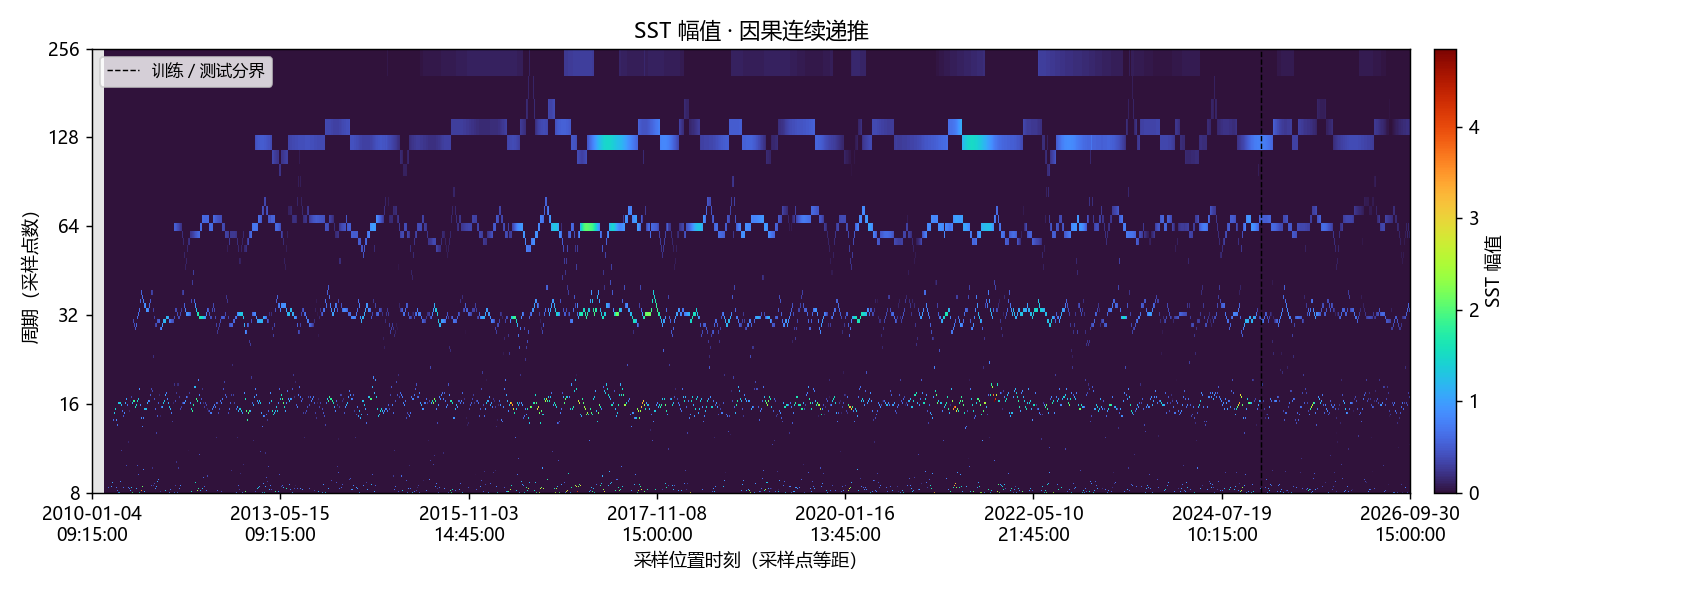

In [8]:
from IPython.display import display,Image
from io import BytesIO
import matplotlib.pyplot as plt

demo_preview_columns = ['sample_id','sample_at','bar_at','sample_side','input_value',
    'input_available_at','available_at','cwt_ready_scale_count','cwt_status','sst_status','sst_reason']
for demo_kind,demo_sequence in demo_sequences.items():
    print(f'核类型：{demo_kind}')
    display(demo_sequence['sequence_df'][demo_preview_columns].tail(8)
        .rename(columns=WAVELET_SEQUENCE_COLUMN_LABELS).rename_axis('row（完整序列末端行）'))
    display(demo_sequence['sequence_df'].groupby(['cwt_status','sst_status','sst_reason'],dropna=False).size().rename('采样点数').reset_index()
        .rename(columns=WAVELET_SEQUENCE_COLUMN_LABELS).rename_axis('row（完整真实状态汇总行）'))

demo_plot_parameters = dict(plot_type='sst_amplitude',x_labels='sample_at',color_scale='linear')
demo_figure,demo_axes = plot_wavelet_sequence(demo_sequences['causal_gammatone']['sequence_df'],demo_banks['causal_gammatone'],
    frequency_grid=demo_frequency_grid,**demo_plot_parameters)
demo_png_buffer = BytesIO()
demo_figure.savefig(demo_png_buffer,format='png',dpi=130)
demo_plot_source = '\n\n'.join(''.join(c['source']) for c in demo_source_book['cells']
    if c['cell_type']=='code' and ''.join(c['source']).lstrip().startswith('def plot_wavelet_sequence'))
demo_figure_identity = dict(source_path=demo_output_paths['causal_gammatone'].relative_to(candidate_root).as_posix(),
    source_content_sha256=demo_installed_identities['causal_gammatone']['output_content_sha256'],
    source_method_sha256=demo_method_source_sha256,
    plot_source_sha256=hashlib.sha256(demo_plot_source.encode()).hexdigest(),parameters=demo_plot_parameters,
    bank_signature=demo_banks['causal_gammatone'].signature,frequency_grid_signature=demo_frequency_grid.signature)
display(Image(data=demo_png_buffer.getvalue()),metadata={'wavelet_figure_identity':demo_figure_identity})
plt.close(demo_figure)
print('完整真实 c03 demo 与一张独立 SST 图已完成；计算和绘图可分别调用。',flush=True)


## 实际验收状态

2026-10-07 已在 `latitude_env_v2` 逐代码单元格执行完整真实 demo，两种核各处理 21,316 点，CWT 复系数／导数／状态和正式 SST 复谱逐项等于已保存 c01、c02 参照。因果 SST 为 16,055 个 ok、5,074 个 partial、186 个 warmup、1 个 failed；Morlet 为 17,403 个 ok、3,788 个 partial、124 个 boundary_incomplete、1 个 failed。两个失败均对应上游首个收益率缺失，没有新增数值失败。

因果序列分为七个连续块，包含训练／测试分界，拼接结果与整段逐列一致，末端滤波状态一致。完整训练前缀不因追加测试输入改变；同一真实输入的 CWT-only 和 Morlet constant 延拓也已实际调用。两种核各保存一份 21,316 行宽表，复读核对局部 Schema、生成身份和内容摘要。Notebook 默认只有一张因果 SST 幅值图，图像 metadata 记录数据与绘图来源。

13 项独立合成契约与边界检查通过，覆盖连续状态、源报价时刻、缺失分段、时间与编号边界、Schema 往返、无重算单图及零幅值相位。临时测试和构建／执行工具暂存 `R00_draft_collection_02/tests/test_rolling_wavelet.py` 及 `R00_draft_collection_02/scripts/*rolling_wavelet*`，测试可用于回归；工具不是正式算法入口，去留尚待确认。